# Physics-Informed Graph Neural Network (PIGNN) for BlueROV2 Dynamics

This notebook runs the full pipeline:
1. **Setup** — Install dependencies, configure paths
2. **Data Generation** — Simulate BlueROV2 trajectories (400 training)
3. **Graph Inspection** — Visualise the heterogeneous graph structure
4. **RK4 Integrator** — Standalone RK4 step wrapping the PIGNN derivative network
5. **Training** — Train with RK4-integrated data loss and direct physics loss
6. **Evaluation** — Rollout predictions vs ground truth


# **Read Prior to Running**

This specfific model took roughly 8 hours to train on an A100 GPU. To save you time I have downloaded the produced .pt files and uploaded them to GitHub as a release.

This notebook is set up to retrieve those weights automatically and use them to run this notebook all the way through. In cell [3] there is an EVAL_ONLY field set to TRUE to load those weights. Setting it to FALSE should train the model as normal.

In short, you should just be able to hit "Run All" in Google Colab with no issues. Please reach out if there proves to be issues with this.

Thank you!

Peter M

## 1. Setup

In [ ]:
# Uncomment and run once to install dependencies:
!pip install torch torch-geometric numpy scipy matplotlib tqdm control numba tensorboard

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 33.9 MB/s eta 0:00:00


In [ ]:
import os
import sys
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import display, HTML

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'CUDA:    {torch.cuda.is_available()}')
print(f'Device:  {device}')


PyTorch: 2.10.0+cpu
CUDA:    False
Device:  cpu


In [ ]:
# Download pretrained weights from GitHub Release
CKPT_DIR        = '/tmp/pignn_v4_noroll_weights'
EXTRACT_DIR     = os.path.join(CKPT_DIR, 'noroll_weights')  # zip extracts into subdir
BEST_MODEL_PATH = os.path.join(EXTRACT_DIR, 'best_model_v3_noroll.pt')
CKPT_PATH       = os.path.join(EXTRACT_DIR, 'training_checkpoint_v3_noroll.pt')
os.makedirs(CKPT_DIR, exist_ok=True)

WEIGHTS_URL = 'https://github.com/PMUSKET2/PIGNN_UUV_3/releases/download/v4-weights/noroll_weights.zip'
WEIGHTS_ZIP = '/tmp/noroll_weights.zip'

# EVAL_ONLY: set True to skip training and load pretrained weights immediately
EVAL_ONLY = True

if not os.path.exists(BEST_MODEL_PATH):
    print('Downloading pretrained weights from GitHub...')
    import urllib.request, zipfile
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_ZIP)
    with zipfile.ZipFile(WEIGHTS_ZIP, 'r') as z:
        z.extractall(CKPT_DIR)
    print(f'Weights extracted to {CKPT_DIR}')
else:
    print('Weights already present, skipping download.')

print(f'Mode: {"EVAL ONLY" if EVAL_ONLY else "TRAINING"}')
print(f'Files: {os.listdir(CKPT_DIR)}')


Weights extracted to /tmp/pignn_v4_noroll_weights
Mode: EVAL ONLY
Files: ['noroll_weights']


## 2. Data Generation

Simulate BlueROV2 trajectories using the 4-DOF Fossen model. This creates training, dev, and test sets.

In [ ]:
# Clone the repo (force fresh clone if stale copy exists)
import os

REPO_URL = 'https://github.com/PMUSKET2/PIGNN_UUV_3.git'
REPO_DIR = '/content/PIGNN_UUV_3'

if os.path.isdir(REPO_DIR):
    # Remove stale clone so we get the latest version
    !rm -rf {REPO_DIR}

!git clone {REPO_URL} {REPO_DIR}

# Set working directory and Python path to the repo root
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Verify the project structure exists
assert os.path.isdir('src'), f'ERROR: src/ not found in {os.listdir(".")}'
print(f'Working directory: {os.getcwd()}')
print(f'Contents: {sorted(os.listdir("."))}')


Cloning into '/content/PIGNN_UUV_3'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 38 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 31.24 KiB | 2.23 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Working directory: /content/PIGNN_UUV_3
Contents: ['.git', 'README.md', 'data', 'models', 'requirements.txt', 'scripts', 'src', 'tests', 'training']


In [ ]:
import control as ct
from src.bluerov import bluerov
from data.data_utility import random_input, random_x0
import numpy as np
import torch

np.random.seed(0)

rov_sys = ct.NonlinearIOSystem(
    bluerov, None,
    inputs=("X", "Y", "Z", "M_z"),
    outputs=("x", "y", "z", "psi", "u", "v", "w", "r"),
    states=("x", "y", "z", "psi", "u", "v", "w", "r"),
    name="bluerov_system",
)

def generate_dataset(name, n_traj, input_type, dt, T_tot, intervals, params=None):
    """Generate and save a trajectory dataset."""
    N = int(T_tot / dt)
    t = np.linspace(0, T_tot, N, dtype=np.float32)
    N_x, N_u = 9, 4

    X = np.zeros((n_traj, N, N_x), dtype=np.float32)
    U = np.zeros((n_traj, N, N_u), dtype=np.float32)
    t_coll = np.zeros((n_traj, N, 1), dtype=np.float32)

    for n in range(n_traj):
        x_0 = random_x0(intervals)
        U[n] = random_input(t, N_u, input_type, params=params)
        if input_type not in ("line", "circle", "figure8"):
            U[n, :, 1] *= 0.1
            U[n, :, 2] = 5 * np.abs(U[n, :, 2])
            U[n, :, -1] *= 0.05

        _, x = ct.input_output_response(rov_sys, t, U[n].T, x_0)
        x = x.T
        X[n, :, :3] = x[:, :3]
        X[n, :, 3] = np.cos(x[:, 3])
        X[n, :, 4] = np.sin(x[:, 3])
        X[n, :, 5:] = x[:, 4:]
        t_coll[n, :, 0] = dt

    os.makedirs(name, exist_ok=True)
    torch.save(torch.from_numpy(t), os.path.join(name, "t.pt"))
    torch.save(torch.from_numpy(U), os.path.join(name, "U.pt"))
    torch.save(torch.from_numpy(X), os.path.join(name, "X.pt"))
    torch.save(torch.from_numpy(t_coll), os.path.join(name, "t_coll.pt"))
    print(f"  {name}: {n_traj} trajectories, {N} steps each")
    return X, U, t


In [ ]:
# Generate datasets — v3: 400 training trajectories to match NODE data budget
dt, T_tot = 0.08, 5.2

datasets = {
    "training_set": {
        "n_traj": 400,  # v3: increased from 100 to match NODE data budget
        "input_type": "noise",
        "intervals": [1.0, 1.0, 1.0, np.pi, 1.0, 0.0, 0.1, 0.0],
    },
    "dev_set": {
        "n_traj": 20,
        "input_type": "sine",
        "intervals": [0.0] * 8,
    },
    "test_set_interp": {
        "n_traj": 20,
        "input_type": "sine",
        "intervals": [0.0] * 8,
        "dt": dt - 0.02,
        "T_tot": 3.9,
    },
    "test_set_extrap": {
        "n_traj": 20,
        "input_type": "sine",
        "intervals": [0.0] * 8,
        "dt": dt + 0.02,
        "T_tot": 6.5,
    },
}

print("Generating datasets...")
generated = {}
for name, cfg in datasets.items():
    d = cfg.get("dt", dt)
    T = cfg.get("T_tot", T_tot)
    X, U, t = generate_dataset(name, cfg["n_traj"], cfg["input_type"], d, T, cfg["intervals"])
    generated[name] = (X, U, t)

print("\nDone!")


Generating datasets...
  training_set: 400 trajectories, 65 steps each
  dev_set: 20 trajectories, 65 steps each
  test_set_interp: 20 trajectories, 65 steps each
  test_set_extrap: 20 trajectories, 65 steps each

Done!


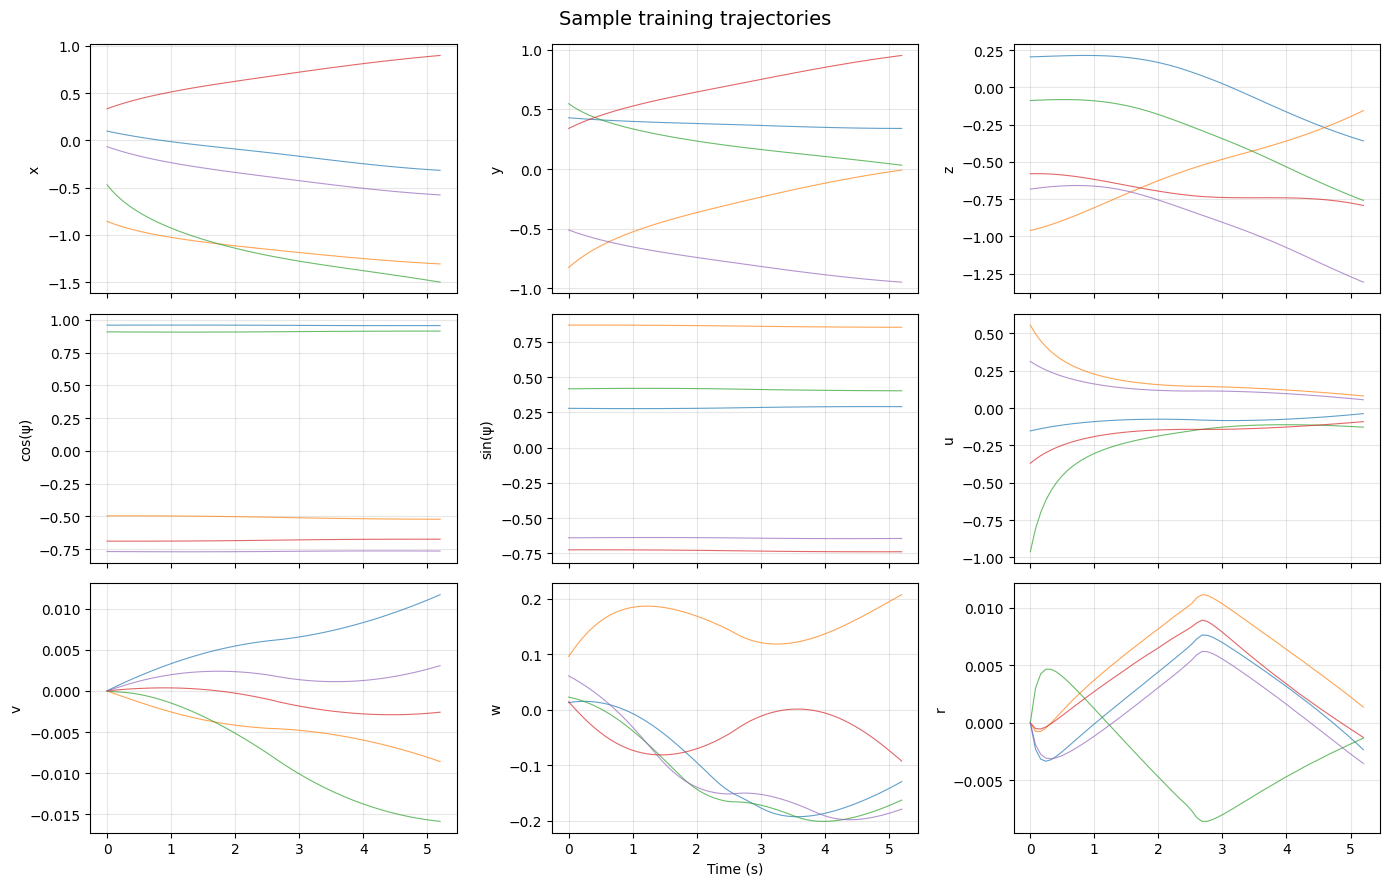

In [ ]:
# Visualise a few training trajectories
X_train, U_train, t_train = generated["training_set"]
state_labels = ["x", "y", "z", "cos(ψ)", "sin(ψ)", "u", "v", "w", "r"]

fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True)
for s, ax in enumerate(axes.flatten()):
    for j in range(min(5, X_train.shape[0])):
        ax.plot(t_train, X_train[j, :, s], alpha=0.7, linewidth=0.8)
    ax.set_ylabel(state_labels[s])
    ax.grid(True, alpha=0.3)
axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Sample training trajectories", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Graph Structure Inspection

Build a sample graph and inspect its topology

In [ ]:
from models.graph_builder import build_graph, allocate_thrusts, NUM_THRUSTERS

# Build a graph from the first time-step of the first training trajectory
sample_state = torch.tensor(X_train[0, 0], dtype=torch.float32)
sample_tau = torch.tensor(U_train[0, 0], dtype=torch.float32)

graph = build_graph(sample_state, sample_tau)

print("=== Heterogeneous Graph Structure ===")
print(f"\nNode types:")
for ntype in graph.node_types:
    x = graph[ntype].x
    print(f"  {ntype:20s}  nodes={x.shape[0]}, features={x.shape[1]}")

print(f"\nEdge types:")
for etype in graph.edge_types:
    ei = graph[etype].edge_index
    ea = graph[etype].edge_attr
    name = f"{etype[0]} --[{etype[1]}]--> {etype[2]}"
    print(f"  {name:45s}  edges={ei.shape[1]}, edge_feat_dim={ea.shape[1]}")

print(f"\nTotal nodes: {sum(graph[nt].x.shape[0] for nt in graph.node_types)}")
print(f"Total edges: {sum(graph[et].edge_index.shape[1] for et in graph.edge_types)}")

=== Heterogeneous Graph Structure ===

Node types:
  hull                  nodes=1, features=9
  thruster              nodes=8, features=8
  hydrodynamic          nodes=1, features=4
  buoyancy              nodes=1, features=6

Edge types:
  thruster --[forces]--> hull                    edges=8, edge_feat_dim=7
  hydrodynamic --[drag]--> hull                  edges=1, edge_feat_dim=8
  buoyancy --[restoring]--> hull                 edges=1, edge_feat_dim=4

Total nodes: 11
Total edges: 10


In [ ]:
# Verify hard constraint: all edges target hull
print("Hard constraint check — all edges target hull:")
for etype in graph.edge_types:
    target = etype[2]
    status = "✓" if target == "hull" else "✗ VIOLATION"
    print(f"  {etype[0]:15s} → {target:10s}  {status}")

# Inspect thruster allocation
print(f"\nThruster allocation for τ = {sample_tau.numpy()}:")
f_alloc = allocate_thrusts(sample_tau.unsqueeze(0)).squeeze()
for i in range(NUM_THRUSTERS):
    print(f"  Thruster {i}: f = {f_alloc[i].item():.4f} N")

Hard constraint check — all edges target hull:
  thruster        → hull        ✓
  hydrodynamic    → hull        ✓
  buoyancy        → hull        ✓

Thruster allocation for τ = [ 0.5720218   0.12271368  4.402594   -0.02195813]:
  Thruster 0: f = 0.0731 N
  Thruster 1: f = 0.3314 N
  Thruster 2: f = 0.0137 N
  Thruster 3: f = -0.4182 N
  Thruster 4: f = 1.1006 N
  Thruster 5: f = 1.1006 N
  Thruster 6: f = 1.1006 N
  Thruster 7: f = 1.1006 N


## 4. Model, RK4 Integrator & Training

Instantiate the PIGNN as a **derivative network** (outputs ẋ, not x̂) and wrap it
in an RK4 integrator.

| | v2 (discrete) | v4 (RK4) | v4-noroll (this run) |
|---|---|---|---|
| Model output | next state x̂(t+dt) | derivative ẋ(t) | derivative ẋ(t) |
| Integration | residual connection (Euler) | RK4 | RK4 |
| Physics loss | AD/jvp through discrete transition | direct: compare ẋ to Fossen RHS | direct: compare ẋ to Fossen RHS |
| Rollout loss | sequential rollout phases | RK4 multi-step rollout | **none** |
| Training phases | 3 | 2 | **1** |

**Rationale:** The PINC paper (Amer et al., 2025) found that incorporating rollout loss
does not consistently enhance learning and in some instances negatively impacts
performance. This run tests that finding on the PIGNN — data loss + physics loss only,
no rollout phase, cleaner convergence signal throughout.


In [ ]:
from models.pignn import PIGNN
from models.model_utility import (
    get_data_sets,
    convert_input_data,
    convert_output_data,
    project_heading,
    weighted_mse_loss,
    get_state_weights,
)
from src.bluerov_torch import bluerov_compute

# ── RK4 integrator (standalone — model predicts ẋ, not x̂) ──────────────
# The model forward pass now outputs the 9D state *derivative* ẋ at the
# current state/control. RK4 takes 4 evaluations at different sub-steps
# and integrates forward by dt with O(dt⁵) local truncation error.
#
# This replaces the residual connection in v2. The graph
# structure, message passing, and readout are unchanged — only the
# interpretation of what the readout head produces has changed.


def rk4_step(model, x, u, dt):
    """
    Advance state x by one RK4 step of size dt.

    Parameters
    ----------
    model : PIGNN (outputs ẋ, shape (B, 9))
    x     : (B, 9)  current state
    u     : (B, 4)  control input (constant over [t, t+dt])
    dt    : float   time step

    Returns
    -------
    x_next : (B, 9)  state at t+dt, with heading projected onto S¹
    """
    device = x.device
    dt_feat = torch.full((x.shape[0], 1), dt, device=device, dtype=x.dtype)

    def f(state):
        # Project heading before each evaluation so the graph is built
        # from a valid (cos ψ, sin ψ) pair.
        state = project_heading(state)
        Z = torch.cat([state, u, dt_feat], dim=-1)
        return model(Z)   # (B, 9)  — derivative ẋ

    k1 = f(x)
    k2 = f(x + 0.5 * dt * k1)
    k3 = f(x + 0.5 * dt * k2)
    k4 = f(x + dt * k3)

    x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    return project_heading(x_next)


# The model now outputs ẋ (derivative), so we validate shape and confirm
# the heading projection in rk4_step produces unit-norm headings.
model = PIGNN(N_in=14, N_out=9, hidden=32, msg_dim=32, n_mp_layers=2).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")

# Test derivative output
x_test = torch.randn(4, 9, device=device)
u_test = torch.randn(4, 4, device=device)
x_test_proj = project_heading(x_test)  # ensure valid heading input
Z_test = torch.cat([x_test_proj, u_test, torch.full((4, 1), 0.08, device=device)], dim=-1)
xdot_test = model(Z_test)
print(f"Derivative output: input {Z_test.shape} -> ẋ {xdot_test.shape}")
assert xdot_test.shape == (4, 9), "Output shape mismatch!"

# Test full RK4 step
x_next_test = rk4_step(model, x_test_proj, u_test, dt=0.08)
norms = torch.sqrt(x_next_test[:, 3]**2 + x_next_test[:, 4]**2)
print(f"RK4 step output shape: {x_next_test.shape}")
print(f"Heading norms after RK4 (should be ~1.0): {norms.detach().cpu().numpy()}")
print("RK4 sanity check OK")


Model parameters: 30,068
Derivative output: input torch.Size([4, 14]) -> ẋ torch.Size([4, 9])
RK4 step output shape: torch.Size([4, 9])
Heading norms after RK4 (should be ~1.0): [0.99999994 1.         1.         1.        ]
RK4 sanity check OK


In [ ]:
# --- Training Configuration (v4-noroll — single phase, no rollout loss) ---
# Per PINC paper findings: rollout loss does not
# consistently improve learning and can negatively impact performance.
# This run uses data loss + physics loss only for the full training duration.
BATCH_SIZE = 32
LR_FACTOR = 0.5
LR_MIN = 1e-5
ALPHA_SMOOTH = 0.6

DEMO_MODE = False  # Set False for full training

if DEMO_MODE:
    PHASES = [
        {'name': 'phase1_data_physics', 'pinn': True, 'rollout': False, 'n_roll': 0,
         'max_epochs': 60, 'patience': 30, 'lr_patience': 15, 'lr_init': 8e-3},
    ]
else:
    PHASES = [
        {'name': 'phase1_data_physics', 'pinn': True, 'rollout': False, 'n_roll': 0,
         'max_epochs': 700, 'patience': 80, 'lr_patience': 35, 'lr_init': 8e-3},
    ]

from torch.utils.data import DataLoader
from data.data_utility import TrajectoryDataset

train_ds = TrajectoryDataset('training_set')
dev_ds = TrajectoryDataset('dev_set')
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False)

# Per-state loss weights from training data
state_weights = get_state_weights(device=device)
state_labels = ['x', 'y', 'z', 'cos(psi)', 'sin(psi)', 'u', 'v', 'w', 'r']
print(f'Training:   {len(train_ds)} trajectories')
print(f'Validation: {len(dev_ds)} trajectories')
print(f'Batch size: {BATCH_SIZE}')
print(f'Mode:       {"DEMO" if DEMO_MODE else "FULL"}')
print(f'Phases:     {len(PHASES)} (data + physics only, no rollout loss)')
print(f'\nPer-state loss weights:')
for lbl, w in zip(state_labels, state_weights.cpu().numpy()):
    print(f'  {lbl:>10s}: {w:.4f}')


Training:   400 trajectories
Validation: 20 trajectories
Batch size: 32
Mode:       FULL
Phases:     1 (data + physics only, no rollout loss)

Per-state loss weights:
           x: 0.0540
           y: 0.2158
           z: 0.0396
    cos(psi): 0.0540
    sin(psi): 0.0540
           u: 0.4856
           v: 5.3958
           w: 0.7588
           r: 1.9425


In [ ]:
import json as _json
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.nn.functional import mse_loss
from tqdm.notebook import trange


# RK4-based loss functions

def rk4_data_loss(model, X, U, dt, state_weights=None):
    """
    One-step data loss via RK4 integration.

    Takes x(t), u(t) → RK4 → x̂(t+dt), compares to x(t+1).
    Because RK4 makes 4 model evaluations per step, this already captures
    multi-step structure better than the v2 Euler residual.

    X    : (B, T, 9)
    U    : (B, T, 4)
    dt   : float
    """
    x_in  = X[:, :-1, :].reshape(-1, 9)   # (B*(T-1), 9)
    u_in  = U[:, :-1, :].reshape(-1, 4)   # (B*(T-1), 4)
    x_tgt = X[:, 1:,  :].reshape(-1, 9)   # (B*(T-1), 9)

    x_pred = rk4_step(model, x_in, u_in, dt)

    if state_weights is not None:
        return weighted_mse_loss(x_pred, x_tgt, state_weights)
    return mse_loss(x_pred, x_tgt)


def rk4_physics_loss(model, X, U, dt):
    """
    Direct physics loss — no AD required.

    Because the model now outputs ẋ directly, the physics loss is simply
    the MSE between the model's derivative and the Fossen RHS evaluated
    at the same (state, control) point. No jvp / AD through a discrete
    transition needed.

    X : (B, T, 9)
    U : (B, T, 4)
    """
    x_flat = X.reshape(-1, 9)              # (B*T, 9)
    u_flat = U.reshape(-1, 4)              # (B*T, 4)

    dt_feat = torch.full((x_flat.shape[0], 1), dt,
                         device=x_flat.device, dtype=x_flat.dtype)
    Z = torch.cat([project_heading(x_flat), u_flat, dt_feat], dim=-1)
    xdot_pred = model(Z)                   # (B*T, 9) — model's derivative

    xdot_physics = bluerov_compute(0, x_flat, u_flat)  # Fossen RHS
    return mse_loss(xdot_pred, xdot_physics)



# Checkpoints

def save_checkpoint(path, model, phase_idx, epoch, best_dev_loss, best_state, history, phase_boundaries):
    torch.save({
        'model_state': model.state_dict(),
        'phase_idx': phase_idx,
        'epoch_in_phase': epoch,
        'best_dev_loss': best_dev_loss,
        'best_state': best_state,
        'history': history,
        'phase_boundaries': phase_boundaries,
    }, path)

def load_checkpoint(path, model, device):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    return ckpt


CKPT_PATH       = os.path.join(CKPT_DIR, 'noroll_weights', 'training_checkpoint_v3_noroll.pt')
BEST_MODEL_PATH = os.path.join(CKPT_DIR, 'noroll_weights', 'best_model_v3_noroll.pt')


# Initialise or resume

model = PIGNN(N_in=14, N_out=9, hidden=32, msg_dim=32, n_mp_layers=2).to(device)

history = {
    'train_data': [], 'train_phys': [],
    'dev_data': [], 'lr': [], 'phase': [],
}
best_dev_loss      = float('inf')
best_state         = None
global_epoch       = 0
phase_boundaries   = []
start_phase_idx    = 0
start_epoch_in_phase = 0

# ── Load pretrained weights (EVAL_ONLY) or train ─────────────────────────
if EVAL_ONLY:
    print('EVAL_ONLY mode — loading pretrained weights...')
    if os.path.exists(CKPT_PATH):
        ckpt = load_checkpoint(CKPT_PATH, model, device)
        best_state       = ckpt['best_state']
        history          = ckpt['history']
        phase_boundaries = ckpt['phase_boundaries']
        best_dev_loss    = ckpt['best_dev_loss']
        global_epoch     = len(history['train_data'])
        print(f'  Loaded checkpoint: {global_epoch} epochs, best dev loss: {best_dev_loss:.6f}')
    elif os.path.exists(BEST_MODEL_PATH):
        best_state = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
        model.load_state_dict(best_state)
        print('  Loaded best_model_v3_noroll.pt (no training history available)')
    else:
        raise FileNotFoundError('No weights found. Check that the zip downloaded correctly in Cell 4.')
    model.eval()
    print('Model ready for evaluation.')

elif os.path.exists(CKPT_PATH):
    print('Found checkpoint - resuming...')
    ckpt = load_checkpoint(CKPT_PATH, model, device)
    loaded_phase = ckpt['phase_idx']
    if loaded_phase >= len(PHASES):
        print(f'  All {len(PHASES)} phases already completed!')
        print(f'  Best dev loss: {ckpt["best_dev_loss"]:.6f}')
        print(f'  Delete checkpoint to retrain: {CKPT_PATH}')
        start_phase_idx = len(PHASES)
        best_dev_loss = ckpt['best_dev_loss']
        best_state    = ckpt['best_state']
        history       = ckpt['history']
        phase_boundaries = ckpt['phase_boundaries']
        global_epoch  = len(history['train_data'])
    else:
        start_phase_idx      = loaded_phase
        start_epoch_in_phase = ckpt['epoch_in_phase'] + 1
        best_dev_loss        = ckpt['best_dev_loss']
        best_state           = ckpt['best_state']
        history              = ckpt['history']
        phase_boundaries     = ckpt['phase_boundaries']
        global_epoch         = len(history['train_data'])
        print(f'  Resuming phase {loaded_phase} from epoch {start_epoch_in_phase}')
        print(f'  Best dev loss so far: {best_dev_loss:.6f}')
else:
    print('No checkpoint found — starting from scratch.')

if not EVAL_ONLY:
    # ── Training loop ──────────────────────────────────────────────────
    for phase_idx in range(start_phase_idx, len(PHASES)):
        phase = PHASES[phase_idx]
        print(f'\n{"="*60}')
        print(f'Phase {phase_idx+1}/{len(PHASES)}: {phase["name"]}')
        print(f'  pinn={phase["pinn"]}, rollout={phase["rollout"]}, n_roll={phase["n_roll"]}')
        print(f'  max_epochs={phase["max_epochs"]}, patience={phase["patience"]}')
        print(f'{"="*60}')

        optimizer = AdamW(model.parameters(), lr=phase['lr_init'], weight_decay=1e-4)
        scheduler = ReduceLROnPlateau(
            optimizer, mode='min', factor=LR_FACTOR,
            patience=phase['lr_patience'], min_lr=LR_MIN,
        )

        no_improve   = 0
        best_phase_loss = float('inf')
        phase_start_epoch = global_epoch
        if global_epoch > 0:
            phase_boundaries.append((global_epoch, phase['name']))

        epoch_start = start_epoch_in_phase if phase_idx == start_phase_idx else 0

        for ep in trange(epoch_start, phase['max_epochs'], desc=phase['name']):
            model.train()
            train_data_loss = 0.0
            train_phys_loss = 0.0
            n_batches = 0

            for X_b, U_b, t_coll_b, time_b in train_loader:
                X_b    = X_b.to(device)
                U_b    = U_b.to(device)

                # RK4 data loss
                l_data = rk4_data_loss(model, X_b, U_b, dt, state_weights)

                #  hysics loss (direct, no AD)
                l_phys = torch.tensor(0.0, device=device)
                if phase['pinn']:
                    l_phys = rk4_physics_loss(model, X_b, U_b, dt)

                # Rollout loss disabled — data + physics only (per PINC paper finding)
                l_total = l_data + 0.5 * l_phys

                optimizer.zero_grad()
                l_total.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

                train_data_loss += l_data.item()
                train_phys_loss += l_phys.item()
                n_batches += 1

            n_batches = max(n_batches, 1)
            avg_data = train_data_loss / n_batches
            avg_phys = train_phys_loss / n_batches

            #Dev evaluation
            model.eval()
            dev_loss = 0.0
            n_dev = 0
            with torch.no_grad():
                for X_d, U_d, _, __ in dev_loader:
                    X_d = X_d.to(device)
                    U_d = U_d.to(device)
                    dev_loss += rk4_data_loss(model, X_d, U_d, dt, state_weights).item()
                    n_dev += 1
            avg_dev = dev_loss / max(n_dev, 1)

            scheduler.step(avg_dev)
            current_lr = optimizer.param_groups[0]['lr']

            history['train_data'].append(avg_data)
            history['train_phys'].append(avg_phys)
            history['dev_data'].append(avg_dev)
            history['lr'].append(current_lr)
            history['phase'].append(phase_idx)
            global_epoch += 1

            # Smooth dev loss tracking
            smooth_dev = (ALPHA_SMOOTH * avg_dev
                          + (1 - ALPHA_SMOOTH) * best_phase_loss
                          if best_phase_loss < float('inf') else avg_dev)

            if smooth_dev < best_dev_loss:
                best_dev_loss = smooth_dev
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                torch.save(best_state, BEST_MODEL_PATH)

            if smooth_dev < best_phase_loss:
                best_phase_loss = smooth_dev
                no_improve = 0
            else:
                no_improve += 1

            if ep % 10 == 0:
                save_checkpoint(
                    CKPT_PATH, model, phase_idx, ep,
                    best_dev_loss, best_state, history, phase_boundaries,
                )
                print(f'  ep {ep:4d} | data {avg_data:.4e} | phys {avg_phys:.4e} '
                      f'| dev {avg_dev:.4e} | lr {current_lr:.2e}')

            if no_improve >= phase['patience']:
                print(f'  Early stop at epoch {ep} (no improvement for {phase["patience"]} epochs)')
                break

        # Save at end of phase
        save_checkpoint(
            CKPT_PATH, model, phase_idx + 1, 0,
            best_dev_loss, best_state, history, phase_boundaries,
        )
        start_epoch_in_phase = 0

    print(f'\nTraining complete. Best dev loss: {best_dev_loss:.6f}')


EVAL_ONLY mode — loading pretrained weights...
  Loaded checkpoint: 700 epochs, best dev loss: 0.000004
Model ready for evaluation.


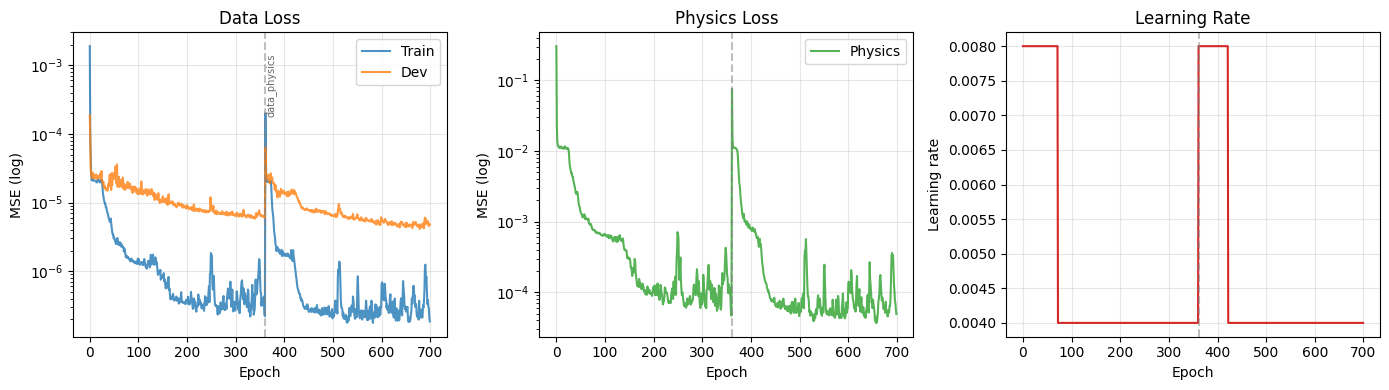

In [ ]:
# Plot training curves with phase boundaries
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Data loss
axes[0].semilogy(history['train_data'], label='Train', alpha=0.8)
axes[0].semilogy(history['dev_data'], label='Dev', alpha=0.8)
for ep, name in phase_boundaries:
    axes[0].axvline(x=ep, color='gray', linestyle='--', alpha=0.5)
    axes[0].text(ep+1, axes[0].get_ylim()[1]*0.5, name.split('_',1)[1],
                fontsize=7, rotation=90, va='top', alpha=0.6)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE (log)')
axes[0].set_title('Data Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Physics loss
axes[1].semilogy(history['train_phys'], label='Physics', color='C2', alpha=0.8)
for ep, _ in phase_boundaries:
    axes[1].axvline(x=ep, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (log)')
axes[1].set_title('Physics Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Learning rate
axes[2].plot(history['lr'], color='C3')
for ep, _ in phase_boundaries:
    axes[2].axvline(x=ep, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning rate')
axes[2].set_title('Learning Rate'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Evaluation — Rollout Predictions

Load the best model and run autoregressive rollouts on the dev set.

In [ ]:
# Load best model
if best_state is not None:
    model.load_state_dict(best_state)
elif os.path.exists(BEST_MODEL_PATH):
    print(f'Loading best model from Drive: {BEST_MODEL_PATH}')
    best_state = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True)
    model.load_state_dict(best_state)
else:
    print('WARNING: No best model found!')

model.eval()
model = model.to(device)


def rollout(model, X_gt, U, dt):
    """
    Autoregressive RK4 rollout from the first time-step.

    Parameters
    ----------
    model : PIGNN (outputs ẋ)
    X_gt  : (1, T, 9)  ground-truth trajectory (used for shape / IC only)
    U     : (1, T, 4)  control inputs
    dt    : float      time step

    Returns
    -------
    X_pred : (T, 9)  predicted trajectory as numpy array
    """
    T = X_gt.shape[1]
    X_pred = torch.zeros(T, 9, device=device)
    X_pred[0] = X_gt[0, 0]  # initial condition from ground truth

    with torch.no_grad():
        for t in range(T - 1):
            x_cur = X_pred[t].unsqueeze(0)       # (1, 9)
            u_cur = U[:, t, :]                    # (1, 4)
            X_pred[t + 1] = rk4_step(model, x_cur, u_cur, dt).squeeze(0)

    return X_pred.cpu().numpy()


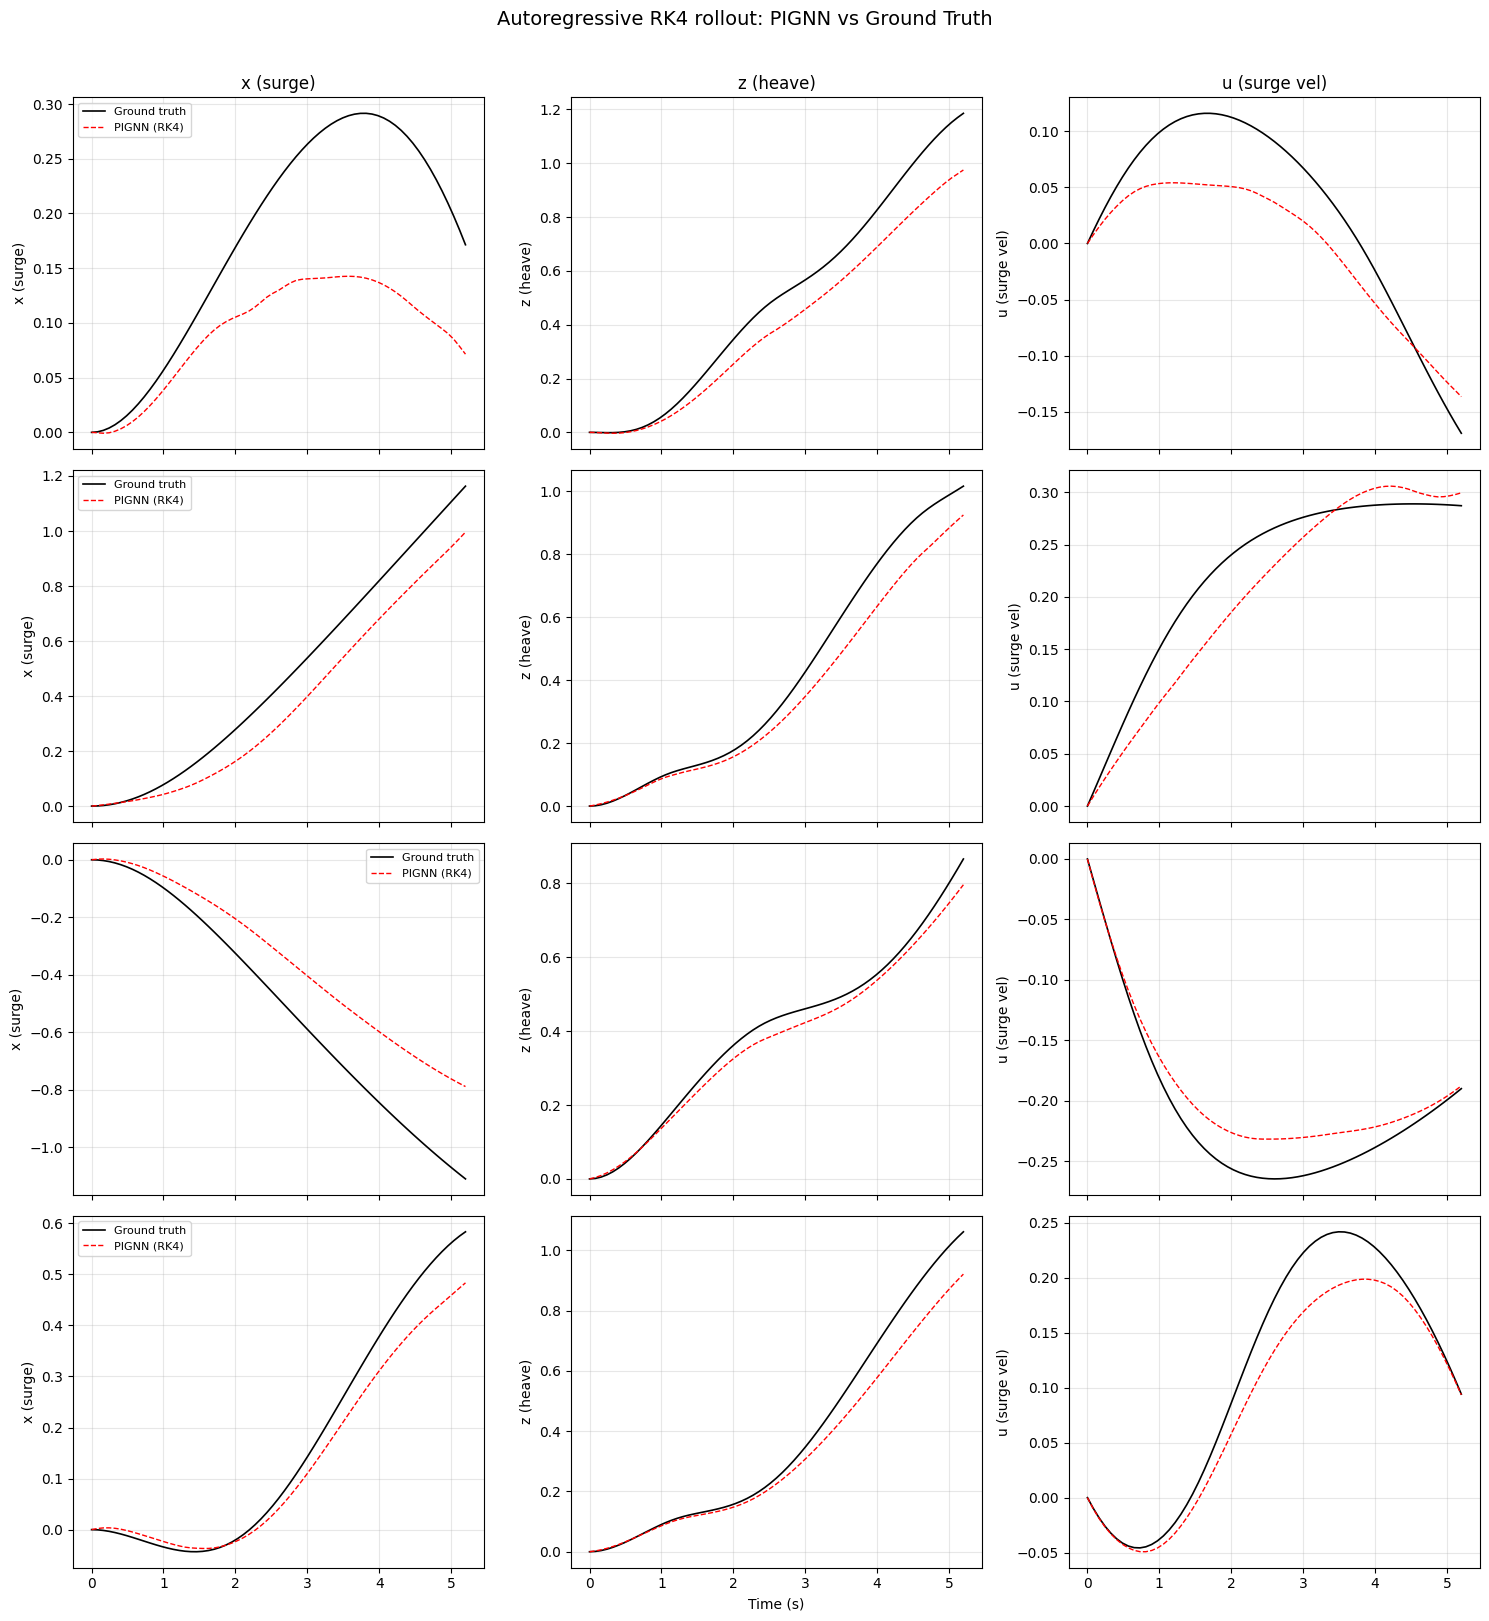

In [ ]:
# Evaluate on dev-set trajectories
n_eval = min(4, len(dev_ds))
indices = np.random.choice(len(dev_ds), n_eval, replace=False)

fig, all_axes = plt.subplots(n_eval, 3, figsize=(15, 4 * n_eval), sharex=True)
if n_eval == 1:
    all_axes = all_axes[np.newaxis, :]

plot_states = [0, 2, 5]  # x, z, u
plot_labels = ["x (surge)", "z (heave)", "u (surge vel)"]

for row, idx in enumerate(indices):
    X_gt, U_gt, tc, tm = dev_ds[idx]
    X_gt_b = X_gt.unsqueeze(0).to(device)
    U_b    = U_gt.unsqueeze(0).to(device)

    X_pred  = rollout(model, X_gt_b, U_b, dt)
    X_gt_np = X_gt.numpy()
    t_axis  = tm[:, 0].numpy()

    for col, (si, sl) in enumerate(zip(plot_states, plot_labels)):
        ax = all_axes[row, col]
        ax.plot(t_axis, X_gt_np[:, si], "k-",  linewidth=1.2, label="Ground truth")
        ax.plot(t_axis, X_pred[:, si],  "r--", linewidth=1.0, label="PIGNN (RK4)")
        ax.set_ylabel(sl)
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.set_title(sl)
        if col == 0:
            ax.legend(fontsize=8)

all_axes[-1, 1].set_xlabel("Time (s)")
fig.suptitle("Autoregressive RK4 rollout: PIGNN vs Ground Truth", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# Evaluation Metrics


state_labels_9 = ['x', 'y', 'z', 'cos(psi)', 'sin(psi)', 'u', 'v', 'w', 'r']
state_labels_8 = ['x [m]', 'y [m]', 'z [m]', 'psi [rad]',
                   'u [m/s]', 'v [m/s]', 'w [m/s]', 'r [rad/s]']
DT = 0.08

def reparam_to_8d(states_9):
    """Convert 9D (cos/sin psi) back to 8D (psi) for position/heading metrics."""
    cos_psi = states_9[..., 3]
    sin_psi = states_9[..., 4]
    psi = np.arctan2(sin_psi, cos_psi)
    return np.concatenate([
        states_9[..., :3],
        psi[..., np.newaxis],
        states_9[..., 5:]
    ], axis=-1)

# Run rollouts on all dev trajectories
n_eval = min(20, len(dev_ds))
all_pred_9 = []  # predicted trajectories (9D)
all_gt_9 = []    # ground truth trajectories (9D)

print(f'Running rollouts on {n_eval} dev trajectories...')
for idx in range(n_eval):
    X_gt, U_gt, tc, tm = dev_ds[idx]
    X_gt_b = X_gt.unsqueeze(0).to(device)
    U_b = U_gt.unsqueeze(0).to(device)
    X_pred = rollout(model, X_gt_b, U_b, dt)
    all_pred_9.append(X_pred)
    all_gt_9.append(X_gt.numpy())

all_pred_9 = np.stack(all_pred_9)  # (N_eval, T, 9)
all_gt_9 = np.stack(all_gt_9)      # (N_eval, T, 9)

# Convert to 8D for position/heading metrics
all_pred_8 = reparam_to_8d(all_pred_9)
all_gt_8 = reparam_to_8d(all_gt_9)

#  1. Per-state MAE (existing metric)
mae_per_state = np.abs(all_pred_9 - all_gt_9).mean(axis=(0, 1))

#  2. Position RMSE over time
pos_err = np.sqrt(np.sum((all_pred_8[:, :, :3] - all_gt_8[:, :, :3])**2, axis=-1))  # (N, T)
pos_rmse = np.sqrt(np.mean(pos_err**2, axis=0))  # (T,)

#  3. Heading RMSE over time
heading_err = np.arctan2(
    np.sin(all_pred_8[:, :, 3] - all_gt_8[:, :, 3]),
    np.cos(all_pred_8[:, :, 3] - all_gt_8[:, :, 3])
)  # (N, T)
heading_rmse = np.sqrt(np.mean(heading_err**2, axis=0))  # (T,)

#  4. Per-state RMSE over time (8D)
state_rmse = np.sqrt(np.mean((all_pred_8 - all_gt_8)**2, axis=0))  # (T, 8)

# 5. VPT (Valid Prediction Time)
mean_pos_err = np.mean(pos_err, axis=0)  # (T,)
exceeded = np.where(mean_pos_err > 0.05)[0]
vpt = exceeded[0] * DT if len(exceeded) > 0 else all_pred_9.shape[1] * DT

#  Print summary
print(f'\n{"="*60}')
print(f'  PIGNN Evaluation Results')
print(f'{"="*60}')
print(f'\n  VPT:                 {vpt:.2f} s')
print(f'  Final pos RMSE:      {pos_rmse[-1]:.4f} m')
print(f'  Final heading RMSE:  {heading_rmse[-1]:.4f} rad')
print(f'  Max pos RMSE:        {pos_rmse.max():.4f} m')
print(f'  One-step dev loss:   {best_dev_loss:.4e}')

print(f'\nPer-state MAE (9D rollout):')
print(f'  {"-"*35}')
for s, label in enumerate(state_labels_9):
    print(f'  {label:>10s}: {mae_per_state[s]:.6f}')
print(f'  {"Overall":>10s}: {mae_per_state.mean():.6f}')


Running rollouts on 20 dev trajectories...

  PIGNN Evaluation Results

  VPT:                 1.28 s
  Final pos RMSE:      0.2606 m
  Final heading RMSE:  0.1116 rad
  Max pos RMSE:        0.2606 m
  One-step dev loss:   4.1941e-06

Per-state MAE (9D rollout):
  -----------------------------------
           x: 0.086041
           y: 0.025032
           z: 0.071373
    cos(psi): 0.001727
    sin(psi): 0.052484
           u: 0.025251
           v: 0.015205
           w: 0.032677
           r: 0.023969
     Overall: 0.037084


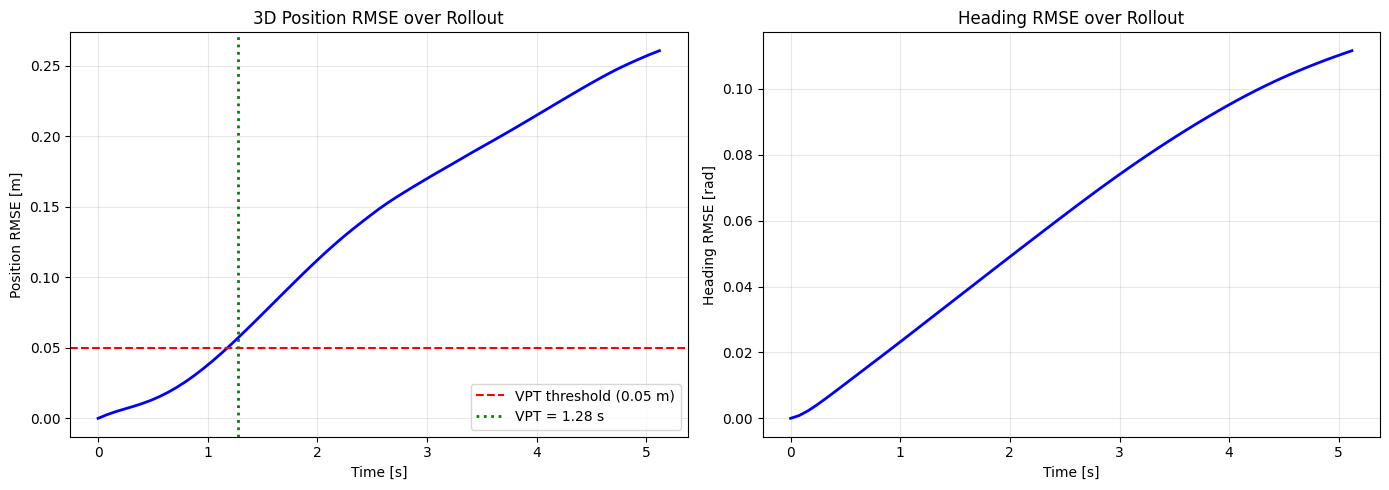

In [ ]:
# Position RMSE + Heading RMSE over time
t_rollout = np.arange(len(pos_rmse)) * DT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Position RMSE
axes[0].plot(t_rollout, pos_rmse, 'b-', lw=2)
axes[0].axhline(y=0.05, color='r', ls='--', label='VPT threshold (0.05 m)')
axes[0].axvline(x=vpt, color='g', ls=':', lw=2, label=f'VPT = {vpt:.2f} s')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Position RMSE [m]')
axes[0].set_title('3D Position RMSE over Rollout')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Heading RMSE
axes[1].plot(t_rollout, heading_rmse, 'b-', lw=2)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Heading RMSE [rad]')
axes[1].set_title('Heading RMSE over Rollout')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


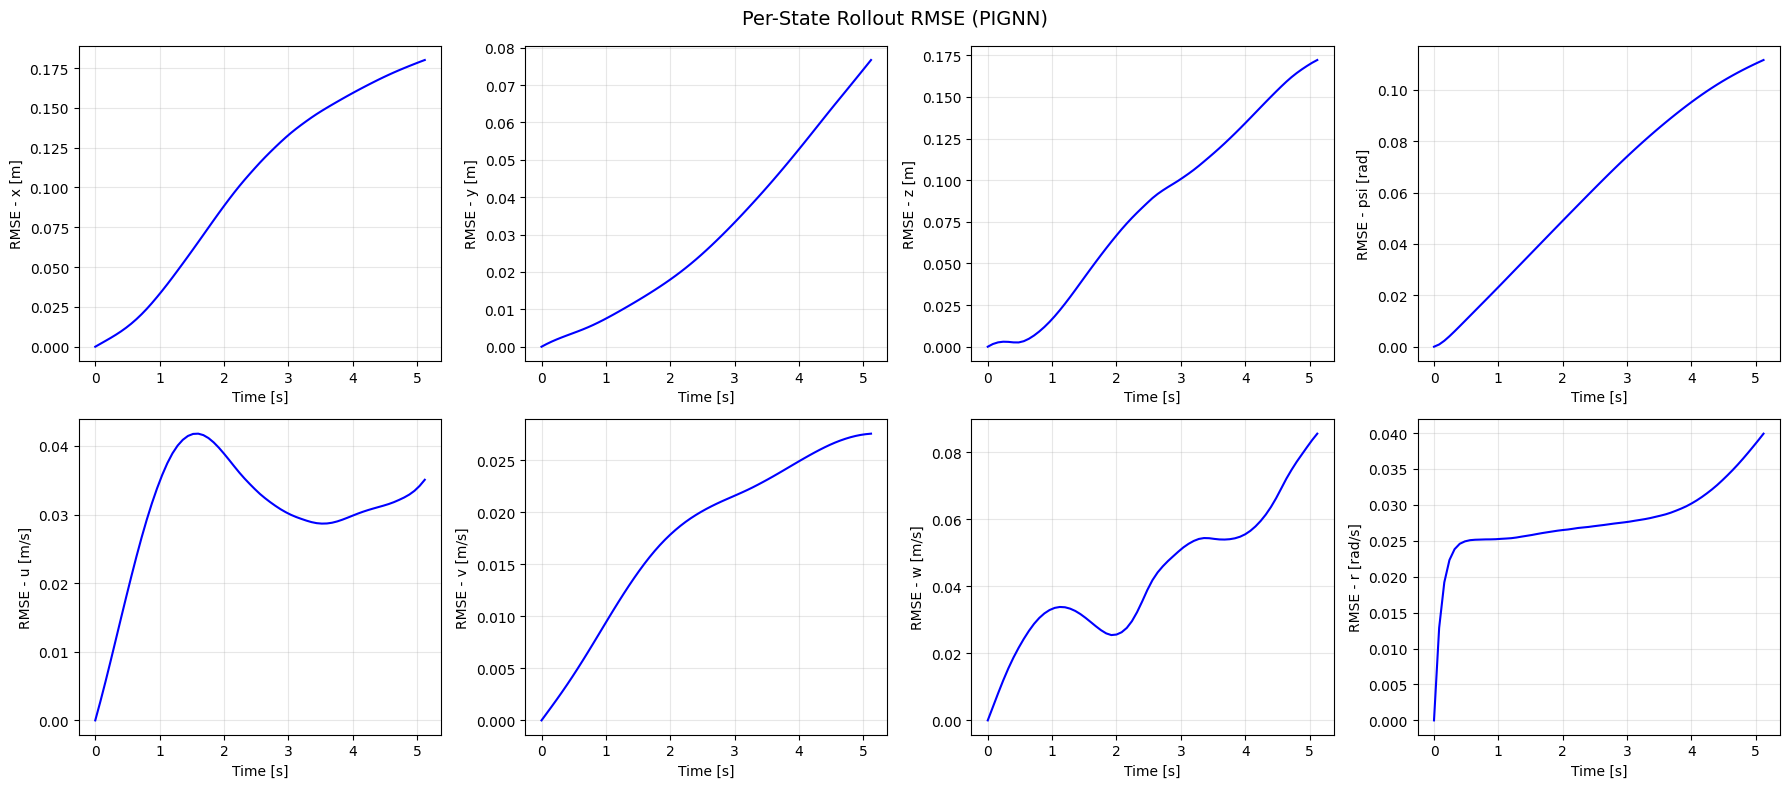

In [ ]:
# Per-state RMSE over time (8D physical states)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    ax.plot(t_rollout, state_rmse[:, i], 'b-', lw=1.5)
    ax.set_ylabel(f'RMSE - {state_labels_8[i]}')
    ax.set_xlabel('Time [s]')
    ax.grid(True, alpha=0.3)
plt.suptitle('Per-State Rollout RMSE (PIGNN)', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Per-state error summary
all_errors = []
for idx in range(min(20, len(dev_ds))):
    X_gt, U_gt, tc, tm = dev_ds[idx]
    X_gt_b = X_gt.unsqueeze(0).to(device)
    U_b = U_gt.unsqueeze(0).to(device)
    X_pred = rollout(model, X_gt_b, U_b, dt)
    all_errors.append(np.abs(X_pred - X_gt.numpy()))

all_errors = np.stack(all_errors)  # (N, T, 9)
mean_err = all_errors.mean(axis=(0, 1))

print("Mean Absolute Error per state variable (rollout):")
print("-" * 40)
for s, label in enumerate(state_labels):
    print(f"  {label:>8s}: {mean_err[s]:.6f}")
print(f"{'Overall':>10s}: {mean_err.mean():.6f}")

Mean Absolute Error per state variable (rollout):
----------------------------------------
         x: 0.086041
         y: 0.025032
         z: 0.071373
  cos(psi): 0.001727
  sin(psi): 0.052484
         u: 0.025251
         v: 0.015205
         w: 0.032677
         r: 0.023969
   Overall: 0.037084


In [ ]:
# Save the best model
os.makedirs("models_saved", exist_ok=True)
save_path = "models_saved/pignn_notebook_best.pt"
torch.save(best_state, save_path)
print(f"Model saved to {save_path}")

Model saved to models_saved/pignn_notebook_best.pt


## 6. Graph Visualisation

Visualise the heterogeneous graph topology using matplotlib.

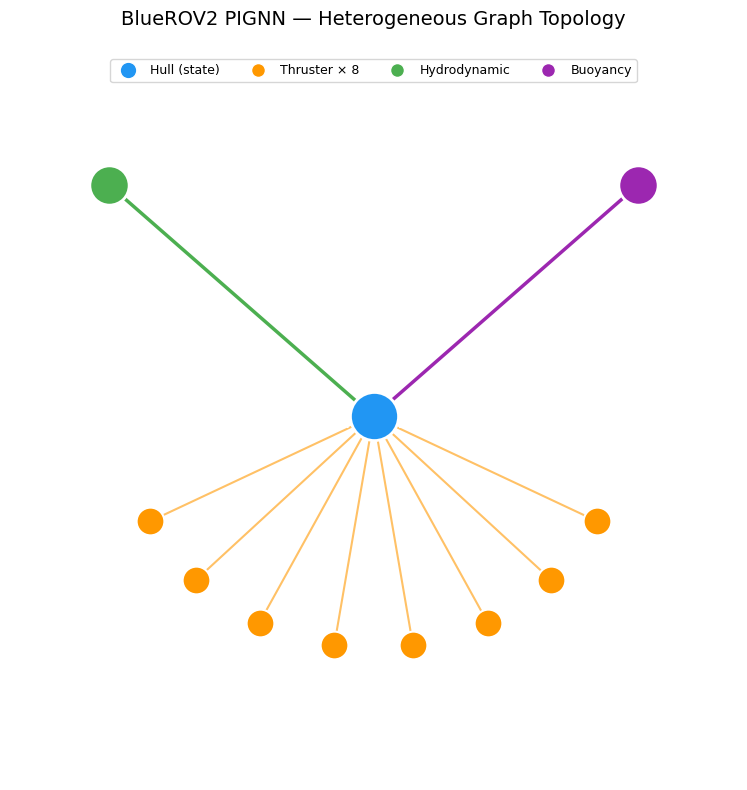

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Node positions for visualisation
positions = {
    "hull": (0.5, 0.5),
    "hydrodynamic": (0.1, 0.85),
    "buoyancy": (0.9, 0.85),
}
# Thrusters arranged in a semicircle below
for i in range(8):
    angle = np.pi * (0.15 + 0.7 * i / 7)
    positions[f"thruster_{i}"] = (0.5 + 0.38 * np.cos(angle), 0.5 - 0.35 * np.sin(angle))

colors = {
    "hull": "#2196F3",
    "thruster": "#FF9800",
    "hydrodynamic": "#4CAF50",
    "buoyancy": "#9C27B0",
}

# Draw edges
for i in range(8):
    tx, ty = positions[f"thruster_{i}"]
    hx, hy = positions["hull"]
    ax.annotate("", xy=(hx, hy), xytext=(tx, ty),
                arrowprops=dict(arrowstyle="->", color=colors["thruster"], lw=1.5, alpha=0.6))

for src in ["hydrodynamic", "buoyancy"]:
    sx, sy = positions[src]
    hx, hy = positions["hull"]
    ax.annotate("", xy=(hx, hy), xytext=(sx, sy),
                arrowprops=dict(arrowstyle="->", color=colors[src], lw=2.5))

# Draw nodes
ax.scatter(*positions["hull"], s=1200, c=colors["hull"], zorder=5, edgecolors="white", linewidth=2)
ax.text(*positions["hull"], "Hull\n(1 node)", ha="center", va="center", fontsize=9, fontweight="bold", color="white")

for i in range(8):
    px, py = positions[f"thruster_{i}"]
    ax.scatter(px, py, s=400, c=colors["thruster"], zorder=5, edgecolors="white", linewidth=1.5)
    ax.text(px, py, f"T{i}", ha="center", va="center", fontsize=7, fontweight="bold", color="white")

for ntype in ["hydrodynamic", "buoyancy"]:
    px, py = positions[ntype]
    ax.scatter(px, py, s=800, c=colors[ntype], zorder=5, edgecolors="white", linewidth=2)
    label = "Hydro\n(1 node)" if ntype == "hydrodynamic" else "Buoyancy\n(1 node)"
    ax.text(px, py, label, ha="center", va="center", fontsize=8, fontweight="bold", color="white")

# Legend
from matplotlib.patches import FancyArrowPatch
legend_elements = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["hull"], markersize=12, label="Hull (state)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["thruster"], markersize=10, label="Thruster × 8"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["hydrodynamic"], markersize=10, label="Hydrodynamic"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=colors["buoyancy"], markersize=10, label="Buoyancy"),
]
ax.legend(handles=legend_elements, loc="upper center", fontsize=9, ncol=4)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("BlueROV2 PIGNN — Heterogeneous Graph Topology", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

---

## Summary

This notebook ran the **v4-noroll** experiment: PIGNN v4 (RK4) trained with
data loss + physics loss only, no rollout loss phase.

**Result:** VPT = 1.28 s, Overall MAE = 0.0371 — best performing configuration.

**Key finding:** Consistent with the PINC paper (Amer et al. 2025), removing the rollout loss
phase improved VPT from 1.12 s (v3 two-phase) to 1.28 s while reducing training time significantly.

| Setting | Value |
|---|---|
| Phases | 1 (data + physics only) |
| Rollout loss | None |
| Max epochs | 700 |
| Early stop patience | 80 |
| Batch size | 32 |
| Weights | `best_model_v4_noroll.pt` |
| Checkpoint | `training_checkpoint_v4_noroll.pt` |

Set `EVAL_ONLY = False` in Cell 4 to retrain from scratch.
